### config & imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from scipy.stats import linregress
from scipy.signal import find_peaks

df = pd.read_csv("od_readings_filtered-Demo_experiment-all_units-20260507114552.csv")
df = df.sort_values("hours_since_experiment_created")

FILES = {
    "Session 1": {
        "gr":  "growth_rates-Demo_experiment-all_units-20260424144615.csv",
        "dos": "dosing_events-Demo_experiment-all_units-20260424144615.csv",
    },
    "Session 2": {
        "gr":  "growth_rates-Demo_experiment-all_units-20260424214253.csv",
        "dos": "dosing_events-Demo_experiment-all_units-20260424214253.csv",
    },
}


df = pd.read_csv("od_readings_filtered-Demo_experiment-all_units-20260507114552.csv")
df = df.sort_values("hours_since_experiment_created")


### Implied growth rate and sine wave dosing (nutrient media)

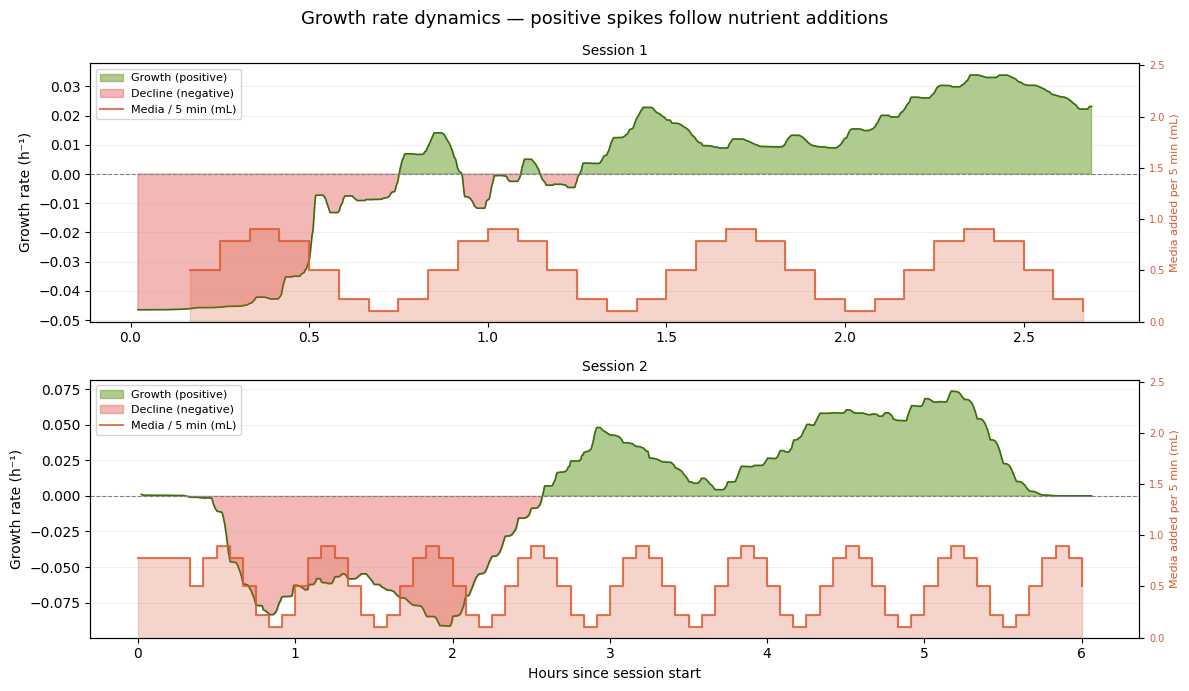

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

for ax, (label, paths) in zip(axes, FILES.items()):
    gr  = pd.read_csv(paths["gr"]).sort_values("hours_since_experiment_created")
    dos = pd.read_csv(paths["dos"])

    t0 = gr["hours_since_experiment_created"].min()
    gr["t_rel"] = gr["hours_since_experiment_created"] - t0
    gr["rate_smooth"] = gr["rate"].rolling(30, center=True).median()

    ax.fill_between(gr["t_rel"], 0, gr["rate_smooth"],
                    where=gr["rate_smooth"] >= 0,
                    color="#639922", alpha=0.5, label="Growth (positive)")
    ax.fill_between(gr["t_rel"], 0, gr["rate_smooth"],
                    where=gr["rate_smooth"] < 0,
                    color="#e24b4a", alpha=0.4, label="Decline (negative)")
    ax.plot(gr["t_rel"], gr["rate_smooth"], color="#3b6d11", lw=1.2)
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_ylabel("Growth rate (h⁻¹)")
    ax.set_title(label, fontsize=10)
    ax.grid(axis="y", lw=0.4, alpha=0.35)

    # ── Secondary axis: rolling media volume (reveals sine wave pattern) ───
    media = dos[dos["event"] == "add_media"].copy()
    media["t_rel"] = media["hours_since_experiment_created"] - t0
    media = media.sort_values("t_rel")

    # Bin into 5-minute windows and sum volume per bin
    # Adjust bin_minutes if the sine wave period is longer/shorter
    bin_minutes = 5
    t_max = media["t_rel"].max()
    bins = np.arange(0, t_max + bin_minutes/60, bin_minutes/60)
    media["bin"] = pd.cut(media["t_rel"], bins=bins, labels=bins[:-1])
    vol_per_bin = media.groupby("bin", observed=True)["volume_change_ml"].sum().reset_index()
    vol_per_bin.columns = ["t_bin", "vol"]
    vol_per_bin["t_bin"] = vol_per_bin["t_bin"].astype(float)

    ax2 = ax.twinx()
    ax2.fill_between(vol_per_bin["t_bin"], 0, vol_per_bin["vol"],
                     color="#d85a30", alpha=0.25, step="post")
    ax2.step(vol_per_bin["t_bin"], vol_per_bin["vol"],
             color="#d85a30", lw=1.5, alpha=0.8, where="post",
             label="Media / 5 min (mL)")

    ax2.set_ylabel("Media added per 5 min (mL)", color="#d85a30", fontsize=8)
    ax2.tick_params(axis="y", labelcolor="#d85a30", labelsize=7)
    ax2.set_ylim(0, vol_per_bin["vol"].max() * 2.8)

    # total = media["volume_change_ml"].sum()
    # ax2.annotate(f"Total: {total:.1f} mL",
    #              xy=(vol_per_bin["t_bin"].iloc[-1], vol_per_bin["vol"].iloc[-1]),
    #              xytext=(-60, 15), textcoords="offset points",
    #              fontsize=7.5, color="#d85a30",
    #              arrowprops=dict(arrowstyle="->", color="#d85a30", lw=0.8))

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")

axes[-1].set_xlabel("Hours since session start")
fig.suptitle("Growth rate dynamics — positive spikes follow nutrient additions", fontsize=13)
plt.tight_layout()
plt.savefig("plot2_growth_rate.png", dpi=150)
plt.show()

### Addition of salt solution to inhibit growth

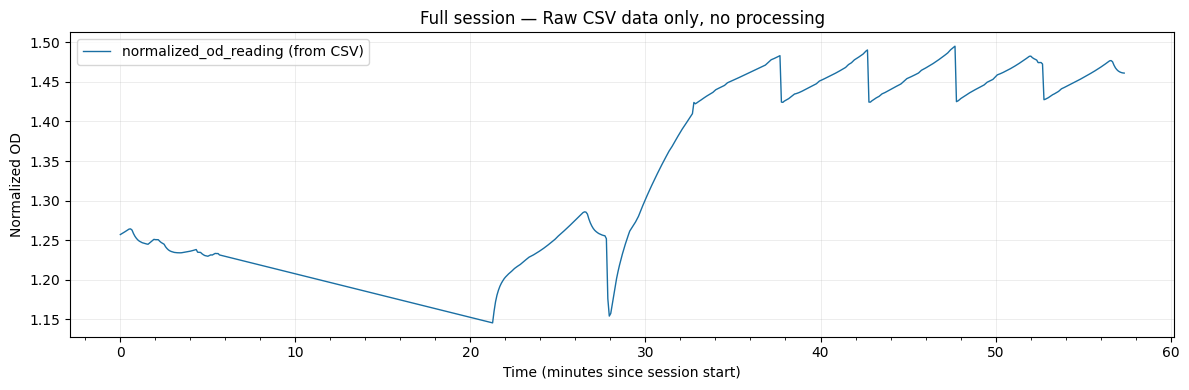

In [4]:
t0 = df["hours_since_experiment_created"].min()
df["t_min"] = (df["hours_since_experiment_created"] - t0) * 60

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["t_min"], df["normalized_od_reading"],
        color="#1a6fa3", lw=1, label="normalized_od_reading (from CSV)")

ax.set_xlabel("Time (minutes since session start)")
ax.set_ylabel("Normalized OD")
ax.set_title("Full session — Raw CSV data only, no processing")
ax.legend()
ax.grid(lw=0.4, alpha=0.4)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
plt.tight_layout()
# plt.savefig("plot_raw_only.png", dpi=150)
plt.show()


Detected 4 drop(s) at minutes: [37.77, 42.77, 47.77, 52.77]

── Segment analysis ──────────────────────────────────────
  Before first drop    | slope: +0.02839 OD/min | R²=0.901 | OD 1.265 → 1.483
  After drop 1         | slope: +0.01294 OD/min | R²=0.994 | OD 1.424 → 1.490
  After drop 2         | slope: +0.01396 OD/min | R²=0.997 | OD 1.425 → 1.495
  After drop 3         | slope: +0.01208 OD/min | R²=0.961 | OD 1.425 → 1.473
  After drop 4         | slope: +0.01023 OD/min | R²=0.882 | OD 1.428 → 1.461


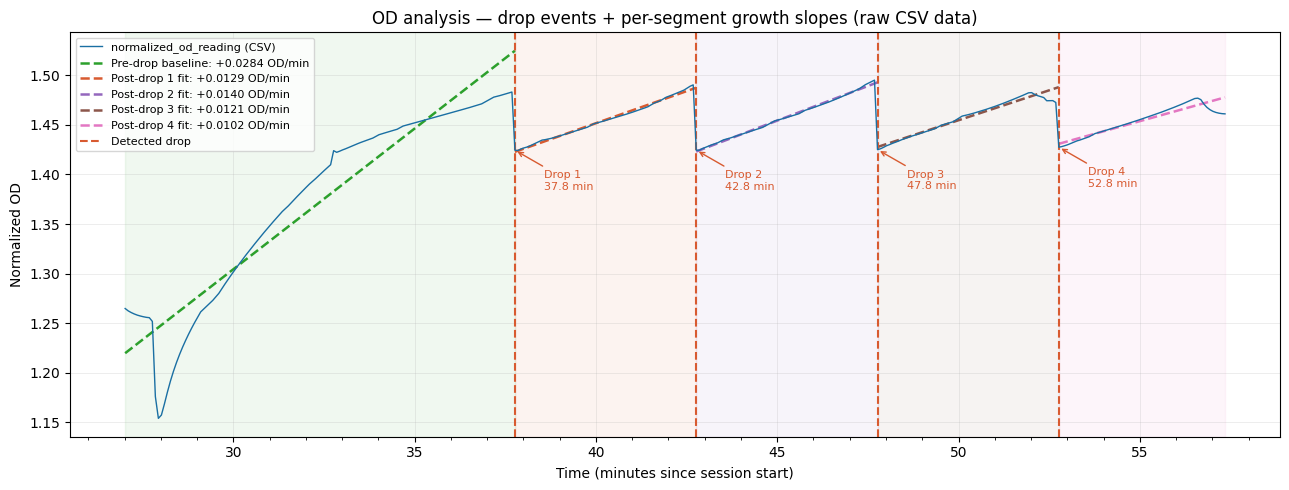

In [5]:

t0 = df["hours_since_experiment_created"].min()
df["t_min"] = (df["hours_since_experiment_created"] - t0) * 60

df = df[df["t_min"] >= 27].reset_index(drop=True)


od = df["normalized_od_reading"]

# ── Drop detection on raw data ─────────────────────────────────────────────
od_diff = od.diff()
drop_threshold = od_diff.mean() - 2.5 * od_diff.std()
drop_mask = od_diff < drop_threshold

# Merge drops within 1 minute of each other
raw_drop_times = df.loc[drop_mask, "t_min"].values
merged_drops = []
for t in raw_drop_times:
    if not merged_drops or t - merged_drops[-1] > 1.0:
        merged_drops.append(t)
        
merged_drops = merged_drops[1:]  # ignore Drop 1 and Drop 2

print(f"Detected {len(merged_drops)} drop(s) at minutes: {[round(t, 2) for t in merged_drops]}")

# ── Per-segment slope analysis ─────────────────────────────────────────────
# Splits the session into segments at each drop and fits a line to each
boundaries = [df["t_min"].min()] + merged_drops + [df["t_min"].max()]
segments = [(boundaries[i], boundaries[i+1]) for i in range(len(boundaries)-1)]

print("\n── Segment analysis ──────────────────────────────────────")
for i, (t_start, t_end) in enumerate(segments):
    seg = df[(df["t_min"] >= t_start) & (df["t_min"] < t_end)]
    if len(seg) < 3:
        continue
    r = linregress(seg["t_min"], seg["normalized_od_reading"])
    label = "Before first drop" if i == 0 else f"After drop {i}"
    print(f"  {label:20s} | slope: {r.slope:+.5f} OD/min | R²={r.rvalue**2:.3f} | "
          f"OD {seg['normalized_od_reading'].iloc[0]:.3f} → {seg['normalized_od_reading'].iloc[-1]:.3f}")

# ── Plot ───────────────────────────────────────────────────────────────────
COLORS = ["#2ca02c", "#d85a30", "#9467bd", "#8c564b", "#e377c2"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df["t_min"], od, color="#1a6fa3", lw=1, label="normalized_od_reading (CSV)", zorder=3)

# Shade segments and draw fit lines
for i, (t_start, t_end) in enumerate(segments):
    seg = df[(df["t_min"] >= t_start) & (df["t_min"] < t_end)]
    if len(seg) < 3:
        continue
    c = COLORS[i % len(COLORS)]
    ax.axvspan(t_start, t_end, alpha=0.07, color=c)
    r = linregress(seg["t_min"], seg["normalized_od_reading"])
    x_fit = np.linspace(t_start, t_end, 200)
    label = "Pre-drop baseline" if i == 0 else f"Post-drop {i} fit"
    ax.plot(x_fit, r.intercept + r.slope * x_fit,
            color=c, lw=1.8, ls="--", label=f"{label}: {r.slope:+.4f} OD/min")

# Mark drops
for i, t in enumerate(merged_drops):
    od_val = od.iloc[(df["t_min"] - t).abs().argmin()]
    ax.axvline(t, color="#d85a30", lw=1.5, ls="--",
               label="Detected drop" if i == 0 else "_")
    ax.annotate(f"Drop {i+1}\n{t:.1f} min",
                xy=(t, od_val),
                xytext=(t + 0.8, od_val - 0.04),
                arrowprops=dict(arrowstyle="->", color="#d85a30"),
                fontsize=8, color="#d85a30")

ax.set_xlabel("Time (minutes since session start)")
ax.set_ylabel("Normalized OD")
ax.set_title("OD analysis — drop events + per-segment growth slopes (raw CSV data)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(lw=0.4, alpha=0.4)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
plt.tight_layout()
# plt.savefig("plot_analysis_raw.png", dpi=150)
plt.show()